## Importe as bibliotecas

In [ ]:
# Configuração inicial
import pandas as pd
import numpy as np
from scipy import stats as st
import seaborn as sns
from matplotlib import pyplot as plt
import re
import pytest

## Definição das configurações de visualização.

In [ ]:
# Variável Global para aleatoriedade
SEED = 42

# Ajuste das quantidade das colunas exibidas
pd.set_option('display.max_columns', 100)

# Estilo e tamanho padrão dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## Leitura dos dados

In [ ]:
df = pd.read_csv('games.csv')
df.head()

In [ ]:
df.columns

In [ ]:
# Padronizando os nomes das colunas para snake_case:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

df.head(1)

In [ ]:
df.info()

## Funções Auxiliares

In [ ]:
def calcular_bins(dados):
    """
    Parâmetros
    ----------
    dados : array-like (list, numpy.ndarray, pandas.Series)
        Conjunto de dados numéricos que será analisado.

    Retorna
    -------
    dict
        Dicionário contendo a quantidade de bins sugerida por três métodos:
        - "sqrt_rule": Regra da raiz quadrada (simples, rápida, baseada em √n)
        - "sturges_rule": Regra de Sturges (log2(n) + 1, boa para distribuições normais)
        - "freedman_diaconis": Regra de Freedman–Diaconis (baseada no IQR, mais robusta a outliers)

    Observações
    -----------
    - √n tende a funcionar bem em distribuições grandes e variadas.
    - Sturges é mais conservadora, útil para distribuições próximas à normal.
    - Freedman–Diaconis se adapta melhor a dados assimétricos e com outliers.

    Exemplo
    -------
    bins = calcular_bins(df['sales'])
    plt.hist(df['sales'], bins=bins['freedman_diaconis'])
    """

    # Calcula o tamanho da amostra (número de observações)
    n = len(dados)
    # Garante que os dados estão em formato NumPy array
    dados = np.asarray(dados)
    # 1. Raiz quadrada do tamanho da amostra
    bins_sqrt = int(np.sqrt(n))

    # 2. Regra de Sturges: log2(n) + 1
    bins_sturges = int(np.log2(n) + 1)

    # 3. Regra de Freedman–Diaconis
    q75, q25 = np.percentile(dados, [75, 25])   # Calcula os quartis
    iqr = q75 - q25                             # Intervalo interquartil (IQR)
    
    # Calcula a largura ideal do bin (bin_width) pela regra de FD
    bin_width = 2 * iqr * n ** (-1/3) if iqr > 0 else 1

    # Calcula o número de bins como o intervalo total / largura
    bins_fd = int((dados.max() - dados.min()) / bin_width) if bin_width > 0 else bins_sturges

    # Retorna os resultados como dicionário
    return {
        "sqrt_rule": bins_sqrt,
        "sturges_rule": bins_sturges,
        "freedman_diaconis": bins_fd
    }


In [ ]:
def outliers_iqr(series):
    """
    Identifica outliers em uma série numérica utilizando o método do Intervalo Interquartil (IQR).

    Parâmetros
    ----------
    series : pandas.Series
        Série numérica (coluna do DataFrame) onde serão identificados os outliers.

    Retorna
    -------
    mask : pandas.Series (boolean)
        Máscara booleana que indica True para os valores considerados outliers.
    lower : float
        Limite inferior para considerar um valor como não outlier.
    upper : float
        Limite superior para considerar um valor como não outlier.

    Exemplo
    -------
    mask, lower, upper = outliers_iqr(df['sales'])
    df[mask]  # retorna apenas os registros considerados outliers
    """

    # Calcula o primeiro quartil (25%)
    q1 = series.quantile(0.25)

    # Calcula o terceiro quartil (75%)
    q3 = series.quantile(0.75)

    # Calcula o intervalo interquartil (IQR = Q3 - Q1)
    iqr = q3 - q1

    # Define o limite inferior (Q1 - 1.5 * IQR)
    lower = q1 - 1.5 * iqr

    # Define o limite superior (Q3 + 1.5 * IQR)
    upper = q3 + 1.5 * iqr

    # Cria uma máscara booleana que marca os valores abaixo do limite inferior ou acima do superior
    mask = (series < lower) | (series > upper)

    # Retorna a máscara e os limites calculados
    return mask, lower, upper


In [ ]:
def outliers_zscore(series):
    """
    Identifica outliers em uma série numérica utilizando o método do Z-score.

    Parâmetros
    ----------
    series : pandas.Series
        Série numérica (coluna do DataFrame) onde serão identificados os outliers.

    Retorna
    -------
    mask : pandas.Series (boolean)
        Máscara booleana que indica True para os valores considerados outliers.
        (valores cujo Z-score absoluto é maior que 3).
    z : pandas.Series (float)
        Série contendo o valor padronizado (Z-score) de cada elemento.

    Observações
    -----------
    - O Z-score mede quantos desvios padrão cada valor está distante da média.
    - Por convenção, valores com |Z| > 3 são considerados outliers.
    - É utilizado ddof=0 para calcular o desvio padrão populacional (consistente com o Z-score).

    Exemplo
    -------
    mask, z = outliers_zscore(df['sales'])
    df[mask]  # retorna apenas os registros considerados outliers
    """

    # Remove valores ausentes (NaN) para cálculo da média e do desvio padrão
    s = series.dropna()

    # Calcula a média da série
    mean = s.mean()

    # Calcula o desvio padrão populacional (ddof=0)
    std = s.std(ddof=0)  # se usássemos ddof=1, seria o desvio padrão amostral

    # Calcula o Z-score: (valor - média) / desvio padrão
    # Se o desvio padrão for 0, usa 1.0 para evitar divisão por zero
    z = (series - mean) / (std if std != 0 else 1.0)

    # Cria uma máscara booleana: True para valores cujo |Z| > 3 (outliers)
    mask = z.abs() > 3

    # Retorna a máscara e a série de Z-scores
    return mask, z


In [ ]:
def safe_mode(series):
    """
    Calcula a moda (valor mais frequente) de uma série numérica ou categórica de forma segura.

    Parâmetros
    ----------
    series : pandas.Series
        Coluna de um DataFrame (numérica ou categórica) para a qual se deseja calcular a moda.

    Retorna
    -------
    valor : qualquer tipo ou float
        Retorna o valor mais frequente (moda) da série.
        Caso não exista uma moda única (ex.: múltiplos valores empatados),
        retorna NaN para evitar erro.

    Observações
    -----------
    - Usa a função mode da biblioteca `statistics`.
    - O método `.dropna()` é aplicado para ignorar valores ausentes (NaN).
    - Em cenários com múltiplas modas, `statistics.mode()` gera `StatisticsError`.
      Esse erro é tratado e a função retorna `np.nan`.

    Exemplo
    -------
    >>> safe_mode(pd.Series([1, 2, 2, 3, 4]))
    2

    >>> safe_mode(pd.Series([1, 1, 2, 2]))  # múltiplas modas
    nan
    """

    # Remove valores ausentes antes do cálculo da moda
    try:
        return series.dropna().mode()
    except StatisticsError:
        # Se houver empate (múltiplas modas), retorna NaN
        return np.nan


In [ ]:
def safe_series_to_int(serie):
    """
    Esta função fará a conversão de FLOAT to INT de toda coluna se for segura.
    Conversão é segura quando não se perdem informações decimais em nenhum registro da coluna.
    Recebe objeto series e retorna o objeto series convertido para INT se for aprovada a conversão.
    Caso não seja aprovada, retorna "Observe a linha X"
    """
    if np.array_equal(serie, serie.astype(int)):
        return serie.astype(int)
    else:
        for idx, item in serie.items():
            if item != int(item):
                return f"Observe a linha {idx}"

        return f"Observe a linha {index}"


# Criando uma função de teste relativa à nova função criada
def test_safe_series_to_int():
    # Caso 1: todos os valores são conversões seguras (floats "inteiros")
    serie1 = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
    resultado1 = safe_series_to_int(serie1)
    esperado1 = serie1.astype(int)
    assert resultado1.equals(esperado1), f"Caso 1 falhou: {resultado1}"

    # Caso 2: índice customizado, valor quebrado (5.35) na posição 4 -> índice real 104
    serie2 = pd.Series(
        [1.0, 2.0, 3.0, 4.0, 5.35, 6.0, 7.0, 8.0, 9.0, 10.0],
        index=[100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
    )
    resultado2 = safe_series_to_int(serie2)
    assert resultado2 == "Observe a linha 104", f"Caso 2 falhou: {resultado2}"

    # Caso 3: valores negativos, todos seguros
    serie3 = pd.Series([-1.0, -2.0, -3.0, -4.0, -5.0, -6.0, -7.0, -8.0, -9.0, -10.0])
    resultado3 = safe_series_to_int(serie3)
    esperado3 = serie3.astype(int)
    assert resultado3.equals(esperado3), f"Caso 3 falhou: {resultado3}"

    print("Todos os testes passaram!")
    return True

print(test_safe_series_to_int())



In [ ]:
def separate_name(name):
    """
    Esta função será usada para separar os respectivos nomes dos jogos
    quando houver duplicidade de registro apenas no nome
    Exemplos: 
    - NBA Live 06 (All region sales)
    - Project Gotham Racing (JP weekly sales)

    Ela retorna uma tupla contendo (name, case) nesta ordem
    """
    location = name.find("(")
    if location == -1:
        return
    else:
        first_group = name[0:location]
        second_group = name[location:len(name)]

        return (first_group.strip(), second_group.strip())

def test_separate_name():
    # Caso 1: nome com sufixo "All region sales"
    entrada1 = "NBA Live 06 (All region sales)"
    resultado1 = separate_name(entrada1)
    esperado1 = ("NBA Live 06", "(All region sales)")
    assert resultado1 == esperado1, f"Caso 1 falhou: {resultado1}"

    # Caso 2: nome com sufixo "JP weekly sales"
    entrada2 = "Project Gotham Racing (JP weekly sales)"
    resultado2 = separate_name(entrada2)
    esperado2 = ("Project Gotham Racing", "(JP weekly sales)")
    assert resultado2 == esperado2, f"Caso 2 falhou: {resultado2}"

    # Caso 3: nome com sufixo "JP sales"
    entrada3 = "The Godfather (JP sales)"
    resultado3 = separate_name(entrada3)
    esperado3 = ("The Godfather", "(JP sales)")
    assert resultado3 == esperado3, f"Caso 3 falhou: {resultado3}"

    print("Todos os testes passaram!")
    return True

print(test_separate_name())
    

In [ ]:
# def safe_changes(game_name, df):
#     """
#     Esta função destina-se a aplicar mudanças estruturais no nosso DataFrame a fim de eliminiar os registros
#     duplicados implícitos que contém substrings como no exemplo abaixo em seu nome:
#     Project Gotham Racing ↔ Project Gotham Racing (JP weekly sales)
#     Tetris 2 ↔ Tetris 2(All region sales) ↔ Tetris 2(weekly jp sales)
#     NBA Live 06 ↔ versões NBA Live 06(All region sales) e NBA Live 06(Weekly american sales)

#     Esta função tratará os dados de todos os 117 jogos que apresentam possíveis implícitos e ajustará seus 
#     registros no DataFrame original, removendo os duplicados

#     Obs 1: Caso os duplicados ocorram em 2 plataformas distintas, vamos criar um "raise ERROR" para analisar
#     o caso individualmente.

#     Obs 2: As únicas métricas que não queremos perder são os dados de venda em milhões. O Critic/User score
#     serão os mesmos do jogo dado como registro original.
#     """
#     df_aux = df[df["name"].str.contains(game_name)].copy()
#     # Condições para tratarmos os registros da mesma natureza
#     # conditions = (
#     #     df["name"].str.contains("(") &
#     #     df["name"].str.contains(")")
#     # )

#     clean_name = separate_name(game_name)[0]
#     df_aux[['name_clean', 'sales_region']] = df_aux['name'].apply(lambda x: pd.Series(separate_name(x)))
#     new_order = ['name','name_clean','sales_region','platform','year_of_release','genre','na_sales','eu_sales','jp_sales','other_sales','critic_score','user_score','rating']
#     df_aux = df_aux[new_order]

#     # Mantém só os registros que são de fato o mesmo jogo (nome limpo == clean_name),
#     # evitando contaminar sequências/edições que batem por substring (ex: "The Godfather II", "The Godfather: Dons Edition")
#     df_aux = df_aux[df_aux['name_clean'] == clean_name]

#     duplicated_mask = df_aux.duplicated(subset=['name_clean', 'platform', 'year_of_release'], keep=False)
#     duplicates = df_aux[duplicated_mask]
#     non_duplicates = df_aux[~duplicated_mask]

#     # Registros sem duplicidade: apenas corrigimos o nome (removendo parênteses)
#     for number in non_duplicates.index:
#         df.at[number, "name"] = clean_name

#     # Agrupa os duplicados por plataforma + ano, e resolve cada grupo de forma independente
#     for (platform, year), group in duplicates.groupby(['platform', 'year_of_release']):
       
#         index_from_duplicated = list(duplicates.index)
#         original_one = index_from_duplicated[0]

#         for number in index_from_duplicated:
#             if number == original_one:
#                 # Alteramos apenas o nome do registro original no DataFrame
#                 df.at[number, "name"] = clean_name
#             else:
#                 #Somando os valores duplicados ao registro original, e atribuindo ao DF original
#                 df.at[original_one, "na_sales"] += duplicates.at[number, "na_sales"]
#                 df.at[original_one, "eu_sales"] += duplicates.at[number, "eu_sales"]
#                 df.at[original_one, "jp_sales"] += duplicates.at[number, "jp_sales"]
#                 df.at[original_one, "other_sales"] += duplicates.at[number, "other_sales"]
#                 df.at[original_one, "name"] = clean_name

#                 # Eliminando o Registro que acabou de ser somado:
#                 df = df.drop(index=number, inplace=True)

#     return f"Concluída Alteração no jogo: {game_name}"


# def df_for_test_changes(df):
#     """
#     Função que gera um Df Test a partir de um DataFrame, e retorna um DataFrame para testes.
#     Ela procura registros que já indicam o problema que queremos resolver.

#     Ao final, o df_test gerado que passará pela função safe_changes() não deverá ter duplicados implícitos.
#     """
    
#     #Selecionando um DataFrame de Teste com 10 jogos aleatórios
#     random_games_list = [
#         'Project Gotham Racing',
#         'Medal of Honor: European Assault',
#         'NBA Live 06',
#         "Tony Hawk's American Wasteland",
#         'Ratchet & Clank: Up Your Arsenal',
#         'Midnight Club 3: DUB Edition',
#         'Tetris 2',
#         'World Soccer Winning Eleven 9',
#         'Yu-Gi-Oh! The Sacred Cards',
#         'Pokémon Mystery Dungeon: Red Rescue Team'
#         ]

#     pattern = "|".join(re.escape(game) for game in random_games_list)
#     df_test = df[df["name"].str.contains(pattern, na=False)]

    
     
#     return df_test

# df_testing = df_for_test_changes(df=df)

# # # Aplicando as mudanças em df_testing, apenas com o jogo "The Godfather"
# # safe_changes("The Godfather", df_testing)

# # #df_testing[df_testing["name"] == "The Godfather"]
# len(df_testing)

# games_list = [game for game in relevant_implicits["name_clean"]]

# for game in games_list:
#     print(safe_changes(game, relevant_implicits))




In [ ]:
import numpy as np

def calculate_pearson(s1, s2, decimals=4):
    """
    Função que calcula o Índice de Correlação Linear de Pearson entre duas
    Series, retornando o valor numérico arredondado e uma classificação
    textual da força da correlação (Muito fraca, Fraca, Moderada, Forte
    ou Perfeita).

    Parameters
    ----------
    s1, s2 : pd.Series
        Séries numéricas a serem correlacionadas.
    decimals : int, default=2
        Número de casas decimais para arredondamento do valor retornado.

    Returns
    -------
    tuple(float, str)
        Valor de correlação arredondado e sua classificação textual.
    """
    pearson = s1.corr(s2)
    pearson_rounded = round(pearson, decimals)

    # Usamos valor absoluto porque a força da correlação independe do sinal
    # (negativa ou positiva) — só a direção da relação muda.
    abs_pearson = abs(pearson_rounded)

    if abs_pearson == 1.0:
        classification = "Perfeita"
    elif abs_pearson >= 0.70:
        classification = "Forte"
    elif abs_pearson >= 0.40:
        classification = "Moderada"
    elif abs_pearson >= 0.20:
        classification = "Fraca"
    else:
        classification = "Muito fraca ou nula"

    if pearson > 0:
        signal = "Positiva"
    elif pearson < 0:
        signal = "Negativa"
    else:
        signal = "Nula"

    return (pearson_rounded, classification, signal)


def test_calculate_pearson():
    # Cada tupla agora inclui o sinal esperado também
    casos = [
        (pd.Series([1, 2, 3, 4, 5]), pd.Series([2, 4, 6, 8, 10]), 1.0, "Perfeita", "Positiva"),
        (pd.Series([1, 2, 3, 4, 5]), pd.Series([10, 8, 5, 3, 1]), -0.99, "Forte", "Negativa"),
        (pd.Series([1, 2, 3, 4, 5]), pd.Series([4, 1, 5, 2, 3]), -0.1, "Muito fraca ou nula", "Negativa"),
    ]

    for s1, s2, expected_value, expected_class, expected_signal in casos:
        result_value, result_class, result_signal = calculate_pearson(s1, s2)

        assert result_value == pytest.approx(expected_value, abs=0.01), (
            f"Valor incorreto: esperado {expected_value}, obtido {result_value}"
        )
        assert result_class == expected_class, (
            f"Classificação incorreta: esperado '{expected_class}', obtido '{result_class}'"
        )
        assert result_signal == expected_signal, (
            f"Sinal incorreto: esperado '{expected_signal}', obtido '{result_signal}'"
        )

    print("✅ 3 casos testados com sucesso (positiva, negativa e fraca).")


test_calculate_pearson()

## Análise Inicial e Limpeza de Dados:

Vamos prosseguir com uma observação inicial do conjunto de dados e tomar decisões importantes, em cada coluna, para melhorar a qualidade dos dados que estamos trabalhando. 
As decisões de cada coluna serão tomadas com base naquilo que será o melhor para o nosso objetivo final: planejar campanhas publicitárias que se convertam em resultados para a empresa Ice.

### Coluna 0: `name`

In [ ]:
column = df["name"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print(f"Top 5 valores mais frequentes: {column.value_counts().head()}")
print("-"*42)
print(column.unique().tolist())

Preencheremos os valores ausentes com "unknown" porque são jogos de 1993 que não interferem tanto na nossa análise.

In [ ]:
df["name"] = df["name"].fillna("unknown")
print("Verificando a presença de ausentes:")
print(df["name"].isna().sum())

Destrinchando um pouco mais os valores desta coluna, vamos entender o comportamento dos duplicados mais a fundo. Observemos o "FIFA 14", um jogo bastante repetido como visto acima.

In [ ]:
fifa14_only = df[df["name"] == "FIFA 14"]
fifa14_only

In [ ]:
# Vamos contar quantas repetições possuem do par NAME-PLATFORM
possible_duplicated = df.duplicated(subset=["name","platform"], keep=False)
df[possible_duplicated]

In [ ]:
implicit_example = df["name"].str.contains("Medal of Honor: European Assault")
df[implicit_example]

#### Duplicados da Coluna `name`

Com os códigos acima, percebemos dois comportamentos interessantes que devemos resolver nessa coluna:

1. Possíveis Duplicados Explícitos: jogos com o mesmo nome, plataforma e ano de lançamento, mostrados em diferentes registros de vendas totais.

2. Possíveis Duplicados Implícitos: jogos que apresentam o mesmo nome, plataforma e ano de lançamento, mas estão divididos por "categorias" impressas nos seus nomes: `(All Region sales)`, `(JP weekly sales)`, `(Old all region sales)`, etc. 

Utilizaremos duas abordagens diferentes para lidar com eles antes de analisar a próxima coluna.

In [ ]:
# Localizando todos os explícitos
# Máscara boleana para identificá-los
possible_duplicated = df.duplicated(subset=["name","platform"], keep=False)
df[possible_duplicated]

Os jogos "unknown" não apresentam informações suficientes para afirmarmos que é o mesmo jogo. Enquanto isso, o jogo "Madden NFL 13" parece apontar para o mesmo jogo, e portanto condensaremos o seu dado de venda `eu_sales` no registro de índice `604`, e excluiremos o registro `16230`.

In [ ]:
# Atualizando o valor do primeiro registro
df.iloc[604,5] = df.iloc[604,5] + df.iloc[16230,5].astype(float)
print(f"Novo valor da célula observada: {float(df.iloc[604,5]):.3}")

# Apagando o registro da linha 16230
df = df.drop(labels=16230)

De maneira semelhante o jogo "Sonic the Hedgehog" para PS3 parece apontar para o mesmo jogo, mas houve uma falha no lançamento da coluna `year_of_release`, e portanto condensaremos o seu dado de venda `eu_sales` e `na_sales` no registro de índice `1745`, e excluiremos o registro `4127`.

In [ ]:
# Atualizando o valor do primeiro registro
df.iloc[1745,5] = df.iloc[1745,5] + df.iloc[4127,5].astype(float)
print(f"Novo valor da célula observada: {float(df.iloc[1745,5]):.3}")

# Apagando o registro da linha 16230
df = df.drop(labels=4127)

É importante ressaltar um detalhe que nós colocaremos nas observações desta sessão:
O jogo **"Need for Speed: Most Wanted"** possui dois registros em PC e dois registros em Xbox360 que possuem anos de lançamento diferentes, e isso não indica um erro ou duplicado no nosso DataFrame, e sim uma prática comum da insdústria de games de vender jogos remasterizados atualizando seus gráficos para tecnologias mais modernas.

Agora vamos observar alguns duplicados implícitos que aparentam apontar para outros registros:

In [ ]:
# # Cria uma máscara booleana que mostra todos os registros 'name' com parenteses e a palavra "sales"
# implicits = df["name"].str.contains(r'\([^)]*sales[^)]*\)', regex=True, na=False)
# df_implicits = df[implicits]
# print(f"Registros de possíveis Duplicados Implícitos: {len(df_implicits)}")
# print('-'*60)
# print(f"Neste grupo, quantidade de registros acima de 1MI USD em vendas totais: {len(df_implicits[df_implicits["total_sales"] > 1])}")


#### Decisão sobre duplicados implícitos:
De toda essa lista, apenas 12 registros tem vendas totais acima de 1 milhão de USD. Visto que a nossa análise é voltada para marketing, e que aproximadamente 87% dos jogos possuem vendas totais abaixo de 1MI de USD (como visto na análise univariada da coluna `total_sales`), vamos tratar os duplicados implícitos apenas destes jogos que tiveram vendas totais relevantes para a nossa análise.

In [ ]:
# relevant_implicits = df_implicits[df_implicits["total_sales"] > 1].copy()
# # Criando novas colunas e re-ordenando o DataFrame
# relevant_implicits[['name_clean', 'sales_region']] = relevant_implicits['name'].apply(lambda x: pd.Series(separate_name(x)))
# new_order = ['name','name_clean','sales_region','platform','year_of_release','genre','na_sales','eu_sales','jp_sales','other_sales','critic_score','user_score','rating']
# relevant_implicits = relevant_implicits[new_order]
# list(relevant_implicits["name_clean"].unique())

# # relevant_implicits["total_sales"].max()
# relevant_implicits

#### Regras de Negócio:

**Vamos definir como regra de negócio que APENAS os registros com name_clean, plataforma, e ano de lançamento são duplicados implícitos**.

**Obs:** Além disso, por ausência de mais informações do negócio, vamos 'ignorar' os registros 'weekly' e somar aos registros originais como valores anuais.

Criaremos uma função **na seção de `Funções Auxiliares`** com o objetivo de corrigir os registros "duplicados implícitos" no nosso DataFrame que irá executar os seguintes passos:
1. Variável principal e única para a função será o nome do jogo.
2. Definir um DataFrame auxiliar com todos os registros que contém o nome do jogo.
3. Aplicar a limpeza do nome do registro com separate_name(x)
4. Fazer checagem Lógica se há duplicados de acordo com o estabelecido na Regra de Negócio
5. Estes duplicados devem ter APENAS 1 categoria de platforma, **caso contrário poderemos cometer o erro de misturar registros de plataformas diferentes para o mesmo jogo**
6. Se houver, fará a substituição de valores e eliminação dos demais registros, aplicando o nome do jogo somente à coluna `name` do nosso df original.
7. Se não ohuver, apenas aplica a mudança da coluna `name` nos registros correspondentes ao DataFrame original

In [ ]:
df[df["name"].str.contains("NBA Live 06")]

#### Observações:

- O mesmo jogo pode ser lançado em várias plataformas, portanto o número de duplicados apenas na coluna `name` é esperado.
- Os dois jogos com `name` ausente foram preenchidos com "unknown" porque não interferem no objetivo da análise.
- Poderemos visualizar os possíveis duplicados observando os pares duplicados `name`-`platform`
- Jogos com o mesmo par `name`-`platform` **são diferentes** se possuírem diferentes `year_of_release` - é uma pratica comum na insdústria de games refazer jogos de muito sucesso no passado com novas features e gráficos (Jogos Remasterizados)
- Uma verificação foi feita fora deste caderno e poderíamos ter alguns duplicados implícitos, ou seja, eram registros do mesmo jogo, mesma plataforma, mesmo ano de lançamento dividos como (All Region sales) e (weekly JP sales) e outros termos semelhantes.

> [!WARNING]
> O jogo "Luminous Arc 2" é um exemplo importante porque fugiu à Regra de Negócio criada para duplicados implícitos, uma vez que o seu ano de lançamento estava ausente no segundo registro. Logo, a nossa função provavelmente não resolverá o problemas semelhantes ao dele.

- O tipo de dado da coluna está correto.

#### Deliberações:

- Podemos criar uma função auxiliar no nosso caderno para identificar e resolver os duplicados impícitos para o nosso DataFrame, condensando os dados em um único registro.

### Coluna 1: `platform`

In [ ]:
column = df["platform"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print(column.unique().tolist())
#print(column.value_counts())
print("-"*42)

In [ ]:
df["platform"] = df["platform"].str.upper()
print(f"Total de valores diferentes: {df["platform"].nunique()}")
print(df["platform"].unique().tolist())

#### Observações:

- A coluna `platform` não possui valores ausentes ou duplicados implícitos.
- Os valores se repetem de forma normal e já esperada, como uma coluna categórica. O tipo de dado está correto.
- A fim de facilitar qualquer filtragem futura, atribuímos a todos os registros os caracteres em 'CAPITAL LETTERS'. Essa alteração foi segura e não reduziu o total de valores diferentes. (Wii e WiiU poderiam causar alguma confusão)

#### Deliberações:

(Nada)

### Coluna 2: `year_of_release`

In [ ]:
column = df["year_of_release"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print(column.unique().tolist())
print(f"\nTop 5 valores mais frequentes: {column.value_counts().head()}")
print("-"*42)

Vamos olhar com mais profundidade para os valores ausentes. Podemos preenchê-los com um número inteiro para que possamos ajustar o tipo de dado da coluna de forma segura, e assim completar esta coluna de valores inteiros de natureza categórica.

In [ ]:
mask1 = df["year_of_release"].isna()
df1 = df[mask1]
df1


In [ ]:
df["year_of_release"] = df["year_of_release"].fillna(0)
print("Verificando a presença de ausentes:")
print(df["year_of_release"].isna().sum())

# Convertendo o tipo de dado de forma segura:
years_changed = safe_series_to_int(df["year_of_release"])
df["year_of_release"] = years_changed
#Verificando o tipo de dado
print(df["year_of_release"].dtype)

#### Observações:

- A coluna `year_of_release` não possui valores duplicados implícitos.
- Observamos 269 registros com ano de lançamento ausente. Rodamos um código acima em um DataFrame filtrado e observamos que estes valores ausentes estão presentes em diversas plataformas.
- Filtramos e observamos também alguns jogos que já tinham o "ano de lançamento" no próprio nome. No entando, jogos como o "Sega Rally 2006" foram lançados no ano exibido no nome enquanto outros jogos como "FIFA Soccer 2004" foram lançados no ano anterior ao exibido.
- Decidimos preencher os valores com um novo valor inteiro "absurdo" para esta categoria (ano 0) para que não tenhamos valores ausentes por enquanto, e **saibamos exatamente quais registros estavam ausentes no início da análise**.


#### Deliberações:

- Não criaremos, ao menos por enquanto, nenhuma função que interprete nomes para preencher a coluna `year_of_release`.
- Criamos neste caderno uma função que recebe um Objeto Series e Verifica conversão segura (sem perder valores decimais). **JÁ PALICADA ACIMA.**

### Coluna 3: `genre`

In [ ]:
column = df["genre"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print(column.unique().tolist())
# print(column.value_counts())
print("-"*42)

In [ ]:
df["genre"] = df["genre"].str.upper()
print(f"Total de valores diferentes: {df["genre"].nunique()}")
print(df["genre"].unique().tolist())

In [ ]:
df[df["genre"].isna()]

In [ ]:
df["genre"] = df["genre"].fillna("unknown")
print(f"Nova contagem de valores ausentes: {df["genre"].isna().sum()}")

#### Observações:

- A coluna `genre` não possui valores duplicados implícitos.
- Os valores se repetem de forma normal e já esperada, como uma coluna categórica. O tipo de dado está correto.
- Os valores ausentes da coluna `genre` estavam nos mesmos registros dos ausentes da coluna `name` que já estavam preenchidos com a palavra "unknown". Seguimos o mesmo critério para este objeto series.
- A fim de facilitar qualquer filtragem futura, atribuímos a todos os registros os caracteres em 'CAPITAL LETTERS'. Essa alteração foi segura e não reduziu o total de valores diferentes.

#### Deliberações:

(Nada)

### Coluna 4: `na_sales`

In [ ]:
column = df["na_sales"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Numérica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Moda da coluna: {float(safe_mode(column.dropna()).iloc[0])}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

### Coluna 5: `eu_sales`

In [ ]:
column = df["eu_sales"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Numérica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Moda da coluna: {float(safe_mode(column.dropna()).iloc[0])}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

### Coluna 6: `jp_sales`

In [ ]:
column = df["jp_sales"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Numérica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Moda da coluna: {float(safe_mode(column.dropna()).iloc[0])}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

### Coluna 7: `other_sales`

In [ ]:
column = df["other_sales"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Numérica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Moda da coluna: {float(safe_mode(column.dropna()).iloc[0])}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

#### Observações:

- Não temos nenhuma linha com valores ausentes em dados de venda.
- Os tipos de dado das colunas está correto.
- É importante já pensar em construir uma nova feature na tabela com vendas totais.

#### Deliberações:

- Criar função de linha que será aplicada para gerar as vendas totais.

### Coluna 8: `critic_score`

In [ ]:
column = df["critic_score"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.dropna().mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Moda da coluna: {float(safe_mode(column.dropna()).iloc[0])}")
print(f"Mínimo: {column.min():.4}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

Observando os dados acima, percebemos que é um tipo de dado float que tem um espaço amostral limitado de 0 a 100. A média com certeza está um pouco abaixo da mediana por conta dos 0,5% (48 notas) abaixo de 3 desvios-padrão dela. 

Ainda assim, podemos considerar que a distribuição das notas dadas pelos críticos não tem muitos valores atípicos, e por isso podemos preencher os valores ausentes com a média e manter o tipo de dado da coluna como float.

In [ ]:
df["critic_score"] = df["critic_score"].fillna(68.97)
print("Verificando a presença de ausentes:")
print(df["critic_score"].isna().sum())
print("-"*42)
print(f"Média da coluna: {df["critic_score"].dropna().mean():.4}")
print(f"Mediana da coluna: {df["critic_score"].median()}")
print(f"Moda da coluna: {float(safe_mode(df["critic_score"].dropna()).iloc[0])}")

#### Observações:

- Optamos por preencher os valores ausentes com a média da coluna uma vez que não tínhamos uma distribuição com muitos valores atípicos.
- Tipo de dado float foi mantido, assim como a média foi mantida. A mediana e a Moda se tornaram o mesmo valor da média.

#### Deliberações:

(nada)

### Coluna 9: `user_score`

Ao tentar começar a observar os dados de user_score, foi fácil perceber que ele continha o tipo de dados equivocado (str), mas isso se deve ao fato da presença de "tbd" como avaliação em alguns registros como veremos abaixo.

In [ ]:
df["user_score"].value_counts()

Antes de qualquer decisão, vamos observar algumas estatísticas descritivas desta coluna, excluindo momentaneamente "tbd" e valores ausentes para transformar os dados em tipo float.

In [ ]:
# Removendo os dados Ausentes
column = df["user_score"].dropna()
# Removendo os registros "tbd"
column = column[column != "tbd"]
column = column.astype(float)

print("Total de dados analisados:")
print(len(column))
print("-"*42)
print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print("-"*42)
print(f"Média da coluna: {column.mean():.4}")
print(f"Mediana da coluna: {column.median()}")
print(f"Mínimo: {column.min():.4}")
print(f"Máximo: {column.max():.4}")
print(f"Amplitude: {round(column.max() - column.min(), 4)}")
print(f"Desvio Padrão: {column.std():.4}")
print("-"*42)

Observando os dados acima, eles também se distribuem como era esperado entre 0 e 10, ou seja, em uma faixa limitada de valores possíveis no espaço amostral. 

A presença dos "tbd" tem o mesmo valor semântico dos valores ausentes: não houve nenhuma crítica ou nota estabelecida por um usuário que possa ser diretamente associada ao par `name - platform`.

Considerando que não temos muitos valores atípicos superiores nem inferiores (apenas 1.3% dos valores observados abaixo de 3 desvios-padrão), vamos preencher tanto os valores ausentes quanto os "tbd" com a média, e transformar todo tipo de dado da coluna em float.

In [ ]:
df["user_score"] = df["user_score"].fillna("7.125")
df["user_score"] = df["user_score"].replace("tbd","7.125")
df["user_score"] = df["user_score"].astype(float)
print("Verificando a presença de ausentes:")
print(df["user_score"].isna().sum())
print("-"*42)
print(f"Média da coluna: {df["user_score"].mean():.4}")
print(f"Mediana da coluna: {df["user_score"].median()}")
print(f"Moda da coluna: {float(safe_mode(df["user_score"].dropna()).iloc[0])}")

#### Observações:

- Optamos por preencher os valores ausentes e os valores "tbd" com a média da coluna uma vez que não tínhamos uma distribuição com muitos valores atípicos.
- Essa mudança permitiu que transformássemos os dados da coluna no tipo float, e consequentemente podendo operar com outros dados numéricos. A mediana e a Moda se tornaram o mesmo valor da média.

#### Deliberações:

- Criar uma função capaz de realizar uma média ponderada entre as avaliações dos usuários e dos críticos, podendo condensar em uma nova feature da tabela uma única nota de avaliação. 

### Coluna 10: `rating`

In [ ]:
column = df["rating"]

print("Verificando a presença de duplicados:")
print(column.duplicated().sum())
print("-"*42)
print("Verificando a presença de ausentes:")
print(column.isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {column.nunique()}")
print(column.unique().tolist())
print("-"*42)
print(column.value_counts())

Resumindo a tabela para um leitor possivelmente leigo no assunto:
| Classificação   | Significado     | Em português           | Indicação                                                   |
| -------- | --------------- | ---------------------- | ----------------------------------------------------------- |
| **E**    | Everyone        | Todos                  | Geralmente adequado para todas as idades                    |
| **M**    | Mature          | Maduro                 | **17 anos ou mais**                                         |
| **T**    | Teen            | Adolescente            | **13 anos ou mais**                                         |
| **E10+** | Everyone 10+    | Todos 10+              | **10 anos ou mais**                                         |
| **K-A**  | Kids to Adults  | Crianças a adultos     | Categoria antiga equivalente aproximadamente ao atual **E** |
| **AO**   | Adults Only     | Somente adultos        | **18 anos ou mais**                                         |
| **EC**   | Early Childhood | Primeira infância      | Categoria antiga destinada a crianças pequenas              |
| **RP**   | Rating Pending  | Classificação pendente | Ainda não recebeu classificação final                       |


Pesquisando um pouco sobre o os índices ESRB de avaliações dos jogos, podemos fazer duas observações relevantes para análise:
- `K-A` é uma clássificação antiga que significa "Kids to Adults", e de certa forma é implícito que seja igual à categoria `E` que significa "everyone".
-  `EC` significa "early childhood". Apesar de ser adequado a todos os públicos, a proposta do jogo é diferente. Vamos manter a sigla, mas sabendo que a classificação foi descontinuada em 2018, e no nosso dataset o jogo mais recente é de 2011.
- A categoria `RP` siginifica "rating pending". Ela aparece três vezes na nossa análise em ocorrências sem valor total de vendas significativo. Portanto, faremos o replacement dela com a mesma string que faremos o preenchimento dos valores ausentes.

In [ ]:
df["rating"] = df["rating"].replace("K-A", "E")
# Preenchendo valores ausentes
df["rating"] = df["rating"].fillna("unknown")
df["rating"] = df["rating"].replace("RP", "unknown")

print("Verificando a presença de ausentes:")
print(df["rating"].isna().sum())
print("-"*42)
# Variável Categórica
print("Valores observados:")
print(f"Total de valores diferentes: {df["rating"].nunique()}")
print(df["rating"].unique().tolist())
print("-"*42)
print(df["rating"].value_counts())

#### Observações:

- Esta coluna categórica fica então com 7 tipos diferentes de jogos, sendo o mais frequente os jogos da categoria preenchida como "unknown".

#### Deliberações:

(nada)

### Resumo do Pré-Processamento de dados

Antes de passarmos para a sessão de Análise Univariada, resolveremos algunas das deliberações dessa sessão, e imprimiremos novamente o comando `df.info()`. O que será resolvido agora:

- Na coluna `name` alguns registros que contam 

In [ ]:
# df[df["name"].str.contains("sales")]

In [ ]:
# df[df["name"].str.contains("Medal of Honor: European Assault")]
df[df["name"].str.contains("NBA Live 06")]

In [ ]:
df.info()

## Engenharia de Características:

Duas oportunidades de criar novas características no nosso DataFrame já se mostram necessárias:

1. Criar uma coluna `total_sales` para conhecer os nossos campeões de vendas globais - coluna responsável por somar todas as outras 4 de vendas.

2. Criar uma coluna `mean_score` para consolidar os "scores" atribuídos ao jogo tanto pelos críticos quanto pelos usuários.

3. Atribuir uma nova ordem nas colunas.

Portanto, vamos incluí-las aqui abaixo.

In [ ]:
def get_total_sales(row):
    """
    Função de linha criada para consolidar o total de vendas em uma nova coluna
    """
    total_sales = (
        row["na_sales"]+row["eu_sales"]+row["jp_sales"]+row["other_sales"]
    )

    return total_sales


def mean_score(row): 
    """
    Função de linha criada para consolidar um score médio entre a avaliação do usuário e dos críticos
    """
    mean_score = (row["critic_score"] + (10*row["user_score"])) / 2

    return round(mean_score, 2)

# Criando uma amostra para testarmos as duas funções acima:
# OBS: Para testar a função, primeiro devemos converter o tipo de dado da coluna 'user_score'
sample = df.sample(15, random_state=SEED).copy()

sample["total_sales"] = sample.apply(func=get_total_sales, axis=1)
sample["mean_score"] = sample.apply(func=mean_score, axis=1)

def test_get_total_sales(sample):
    for idx, row in sample.iterrows():
        # cálculo independente, via .sum() ao invés de soma manual
        expected = row[["na_sales", "eu_sales", "jp_sales", "other_sales"]].sum()
        result = get_total_sales(row)
        assert result == pytest.approx(expected), (
            f"Linha {idx}: esperado {expected}, obtido {result}"
        )
    print(f"✅ {len(sample)} linhas verificadas com sucesso.")


def test_mean_score(sample):
    for idx, row in sample.iterrows():
        expected = round((row["critic_score"] + (10 * row["user_score"])) / 2, 2)
        result = mean_score(row)
        assert result == pytest.approx(expected), (
            f"Linha {idx}: esperado {expected}, obtido {result}"
        )
    print(f"✅ {len(sample)} linhas verificadas com sucesso.")


test_get_total_sales(sample)
test_mean_score(sample)


In [ ]:
# Criando coluna com total de vendas
df["total_sales"] = df.apply(func=get_total_sales, axis=1)

# Criando coluna com média de vendas
df["mean_score"] = df.apply(func=mean_score, axis=1)

In [ ]:
# Reordenando as colunas
df = df[['name','platform','year_of_release','genre','total_sales','na_sales','eu_sales','jp_sales','other_sales','critic_score','user_score','mean_score','rating']]

df.head()


# Análise do Primeiro Momento Estatístico

## Análise Univariada:

Nesta etapa vamos avaliar como se distribuem as variáveis das features do nosso DataFrame. Vamos excluir dessa análise a coluna `name` porque os dados associados a ela são os mais importantes.

### Coluna `platform`:

In [ ]:
platform_hbp = df["platform"].value_counts().reset_index() #DataFrame Object

platform_ax = sns.barplot(x="count", y="platform", data=platform_hbp)

plt.show(platform_ax)


É interessante que nessa figura podemos visualizar claramente as Top5 plataformas com mais jogos lançados no nosso DataFrame. O sony "PS2" e o nintendo "DS" lideram as duas primeiras posições com grande vantagem, seguidos do sony "PS3", nintendo "WII" e microsoft "X360".

### Coluna `year_of_release`:

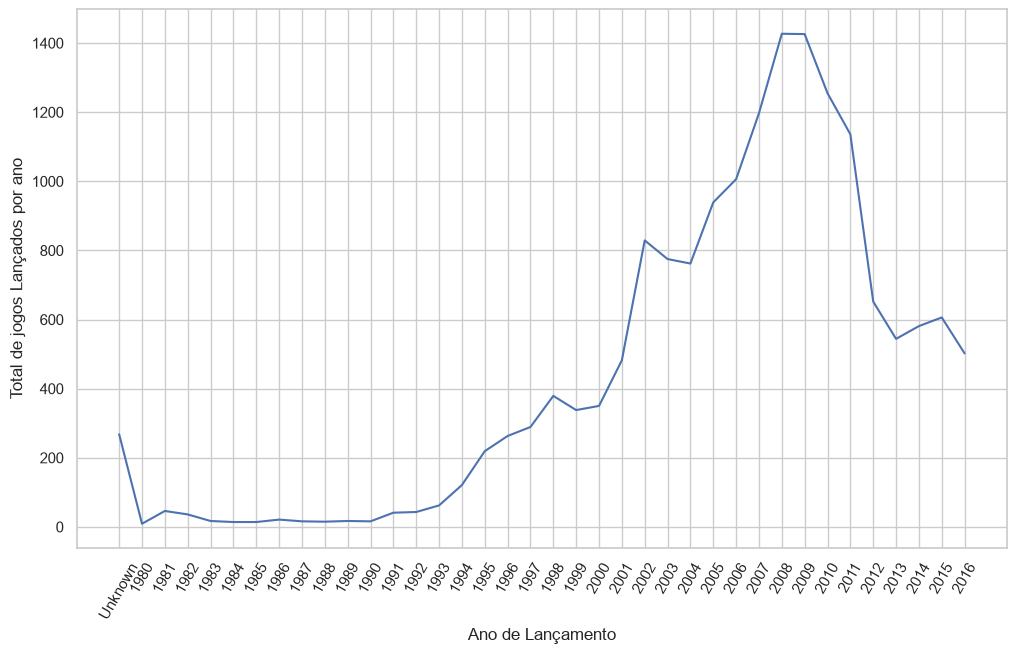

In [220]:
year_of_release_lines = df["year_of_release"].value_counts().reset_index() #DataFrame Object
year_of_release_lines = year_of_release_lines.sort_values(by="year_of_release", axis=0)
year_of_release_lines["year_of_release"] = year_of_release_lines["year_of_release"].astype(str)
year_of_release_lines["year_of_release"] = year_of_release_lines["year_of_release"].replace("0", "Unknown")

sns.lineplot(data=year_of_release_lines, x="year_of_release", y="count")
plt.xticks(rotation=60)
plt.xlabel(xlabel="Ano de Lançamento")
plt.ylabel(ylabel="Total de jogos Lançados por ano")
plt.show()

Observando o gráfico acima, vemos a marca inicial com os 269 jogos que possuíam ano de lançamento ausente, agora marcados como Unknown.

Podemos notar tamém que o mercado de games começou a produzir muito mais a partir de 1995, quando os jogos começaram a entrar nas casas dos jovens, e as plataformas começaram a se expandir.

Observamos também que o maior número de jogos lançados em 1 ano está entre 2007 e 2011.

### Coluna `genre`:

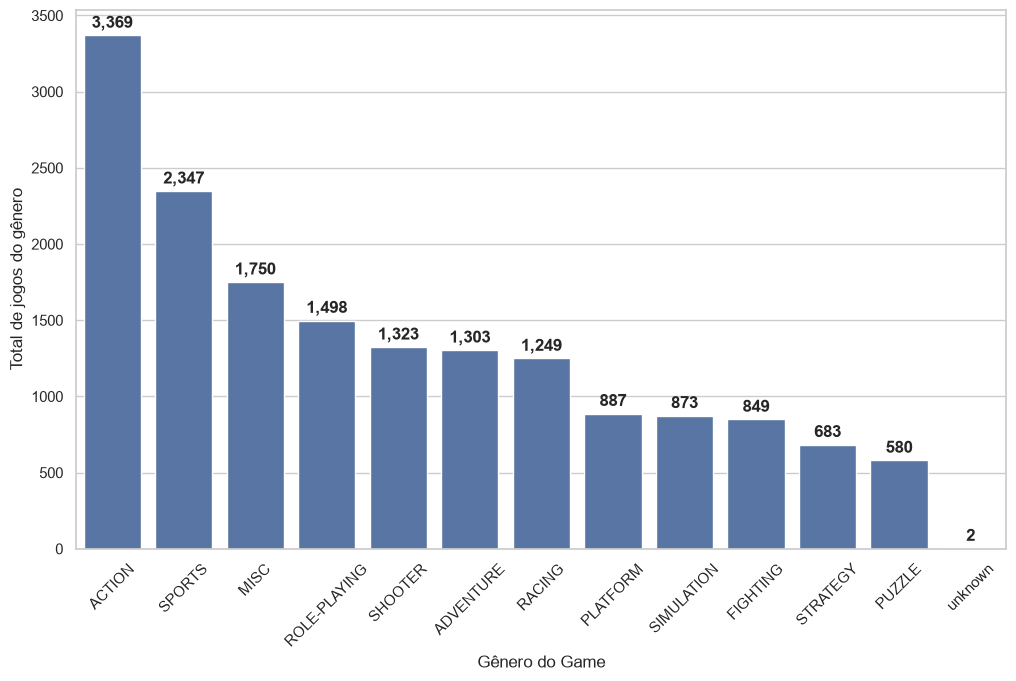

In [196]:
genre_bp = df["genre"].value_counts().reset_index() #DataFrame Object

genre_ax = sns.barplot(data=genre_bp, x="genre", y="count")

# Adiciona rótulos acima de cada barra
for p in genre_ax.patches:
    genre_ax.annotate(
        f'{p.get_height():,.0f}',                       # valor da barra formatado
        (p.get_x() + p.get_width()/2, p.get_height()),  # posição: centro e topo da barra
        ha='center', va='bottom', fontweight='bold',    # alinhamento central e negrito
        xytext=(0, 3), textcoords='offset points'       # deslocamento de 3 pontos acima da barra
    )

plt.xticks(rotation=45)
plt.xlabel(xlabel="Gênero do Game")
plt.ylabel(ylabel="Total de jogos do gênero")

plt.show(genre_ax)

Agora podemos observar os gêneros dos jogos lançados no nosso Dataframe, com um grande destaque para os jogos de ação e esportes, que representam uma parcela significativa do total, sendo estes os dois mais frequentes.

### Coluna `total_sales`:

Vamos analisar agora a nossa coluna nova `total_sales` e ver como os dados comtidos nela se distribuem, e como isso também é refletido nas demais vendas.

In [ ]:
total_sales_dist = df["total_sales"].reset_index() #DataFrame Object
bins = calcular_bins(total_sales_dist) # Usaremos sqrt_rule

total_sales_hist = sns.histplot(data=total_sales_dist,bins=bins["sqrt_rule"], x="total_sales")
plt.xlabel(xlabel="Vendas Totais em todas as regiões - Em milhões de USD")
plt.ylabel(ylabel="Quantidade de Jogos")

plt.show(total_sales_hist)

In [ ]:
total_sales_box = sns.boxplot(data=total_sales_dist, x="total_sales")
# Define o título do gráfico
plt.title('Boxplot de Vendas Totais(USD)')

# Define o rótulo do eixo X
plt.xlabel('Soma das Vendas em todas as regiões (USD)')

# Exibe o gráfico na tela
plt.show(total_sales_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = total_sales_dist["total_sales"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo de 1MI USD em {s.name}s: {st.percentileofscore(s, 1):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Podemos observar na coluna que consolida as vendas totais uma distribuição onde podemos concluir que a maior parte dos jogos não chegou a atingir 1 milhão de dólares em vendas totais (cerca de 87,62%).

Sendo assim era de se esperar uma distribuição com muitos valores concentrados próximos de zero, e com certeza uma grande presença de Outliers que influenciam muito a média - mais de 75% dos valores de venda estão abaixo da média.

O esperado é que esse comportamento se repita quando analisarmos as vendas por região abaixo neste caderno.

### Coluna `na_sales`:

Vamos analisar agora a coluna `na_sales` - Vale relembrar que esta coluna se refere às vendas de cada jogo na América do Norte

In [ ]:
na_sales_dist = df["na_sales"].reset_index() #DataFrame Object
bins = calcular_bins(na_sales_dist) # Usaremos sqrt_rule

na_sales_hist = sns.histplot(data=na_sales_dist,bins=bins["sqrt_rule"], x="na_sales")
plt.xlabel(xlabel="Vendas na América do Norte - Em milhões de USD")
plt.ylabel(ylabel="Quantidade de Jogos")
plt.show(na_sales_hist)

In [ ]:
na_sales_box = sns.boxplot(data=na_sales_dist, x="na_sales")
# Define o título do gráfico
plt.title('Boxplot de Vendas na América do Norte(USD)')

# Define o rótulo do eixo X
plt.xlabel('Soma das Vendas na América do Norte(USD)')

# Exibe o gráfico na tela
plt.show(na_sales_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = na_sales_dist["na_sales"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo de 1MI USD em {s.name}s: {st.percentileofscore(s, 1):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Podemos observar na coluna que consolida as vendas da América do Norte uma distribuição onde podemos concluir que a maior parte dos jogos não chegou a atingir 1 milhão em vendas totais (cerca de 94,55%).

Sendo assim era de se esperar, assim como em vendas totais uma distribuição com muitos valores concentrados próximos de zero, e com certeza uma grande presença de Outliers que influenciam muito a média - mais de 75% dos valores de venda continuam abaixo da média.

### Coluna `eu_sales`:

Vamos analisar agora a coluna `eu_sales` - Vale relembrar que esta coluna se refere às vendas de cada jogo na União Europeia em milhões de dólares americanos.

In [ ]:
eu_sales_dist = df["eu_sales"].reset_index() #DataFrame Object
bins = calcular_bins(eu_sales_dist) # Usaremos sqrt_rule

eu_sales_hist = sns.histplot(data=eu_sales_dist,bins=bins["sqrt_rule"], x="eu_sales")
plt.xlabel(xlabel="Vendas na Europa - Em milhões de USD")
plt.ylabel(ylabel="Quantidade de Jogos")
plt.show(eu_sales_hist)

In [ ]:
eu_sales_box = sns.boxplot(data=eu_sales_dist, x="eu_sales")
# Define o título do gráfico
plt.title('Boxplot de Vendas na Europa(USD)')

# Define o rótulo do eixo X
plt.xlabel('Soma das Vendas na Europa(USD)')

# Exibe o gráfico na tela
plt.show(eu_sales_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = eu_sales_dist["eu_sales"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo de 1MI USD em {s.name}s: {st.percentileofscore(s, 1):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Podemos observar na coluna que consolida as vendas na Europa uma distribuição onde podemos concluir que a maior parte dos jogos não chegou a atingir 1 milhão em vendas totais (cerca de 97,18%).

Desta vez, o valor mais frequente da coluna é 0.0. Isso significa que a maioria dos jogos não chegou a 10 mil dólares em venda e permanece zerada no nosso DataFrame.

### Coluna `jp_sales`:

Vamos analisar agora a coluna `jp_sales` - Vale relembrar que esta coluna se refere às vendas de cada jogo no Japão em milhões de dólares americanos.

In [ ]:
jp_sales_dist = df["jp_sales"].reset_index() #DataFrame Object
bins = calcular_bins(jp_sales_dist) # Usaremos sqrt_rule

jp_sales_hist = sns.histplot(data=jp_sales_dist,bins=bins["sqrt_rule"], x="jp_sales")
plt.xlabel(xlabel="Vendas no Japão - Em milhões de USD")
plt.ylabel(ylabel="Quantidade de Jogos")
plt.show(jp_sales_hist)

In [ ]:
jp_sales_box = sns.boxplot(data=jp_sales_dist, x="jp_sales")
# Define o título do gráfico
plt.title('Boxplot de Vendas no Japão(USD)')

# Define o rótulo do eixo X
plt.xlabel('Soma das Vendas no Japão(USD)')

# Exibe o gráfico na tela
plt.show(jp_sales_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = jp_sales_dist["jp_sales"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo de 1MI USD em {s.name}s: {st.percentileofscore(s, 1):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Podemos observar na coluna que consolida as vendas no Japão uma distribuição onde podemos concluir que a maior parte dos jogos não chegou a atingir 1 milhão em vendas totais (cerca de 98,56%).

Desta vez, o valor mais frequente da coluna é 0.0, assim como a mediana (o percentil 50) também é 0.0. Isso significa que a maioria dos jogos não chegou a 10 mil dólares em venda e permanece zerada no nosso DataFrame, e que esses valores representam mais de 50% da amostra.

### Coluna `other_sales`:

Vamos analisar agora a coluna `other_sales` - Vale relembrar que esta coluna se refere às vendas de cada jogo nas demais regiões do globo em dólares americanos.

In [ ]:
other_sales_dist = df["other_sales"].reset_index() #DataFrame Object
bins = calcular_bins(other_sales_dist) # Usaremos sqrt_rule

other_sales_hist = sns.histplot(data=other_sales_dist,bins=bins["sqrt_rule"], x="other_sales")
plt.xlabel(xlabel="Vendas em outras regiões - Em milhões de USD")
plt.ylabel(ylabel="Quantidade de Jogos")
plt.show(other_sales_hist)

In [ ]:
other_sales_box = sns.boxplot(data=other_sales_dist, x="other_sales")
# Define o título do gráfico
plt.title('Boxplot de Vendas em outras regiões(USD)')

# Define o rótulo do eixo X
plt.xlabel('Soma das Vendas em outras regiões(USD)')

# Exibe o gráfico na tela
plt.show(other_sales_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = other_sales_dist["other_sales"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo de 1MI USD em {s.name}s: {st.percentileofscore(s, 1):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Consolidando as análises das colunas com dados de vendas, podemos esperar outliers campeões de venda bem distantes da média.

Voltando a nossa análise para o Marketing da Ice, esses campeões de venda devem também apontar para padrões de demanda confirmados em transações - e estes indícios são fundamentais para o nosso planejamento.

### Coluna `mean_score`:

Vamos analisar agora a coluna `mean_score` - essa foi a coluna criada para consolidar as pontuações dadas pelos usuários e pelos críticos. Observemos o seu comportamento:

In [ ]:
mean_score_dist = df["mean_score"].reset_index() #DataFrame Object
bins = calcular_bins(mean_score_dist) # Usaremos sturges_rule

mean_score_hist = sns.histplot(data=mean_score_dist,bins=bins["sturges_rule"], x="mean_score")
plt.xlabel(xlabel="Média das Notas atribuídas")
plt.ylabel(ylabel="Frequência")
plt.show(mean_score_hist)

In [ ]:
mean_score_box = sns.boxplot(data=mean_score_dist, x="mean_score")
# Define o título do gráfico
plt.title('Boxplot de Notas médias atribuídas aos jogos')

# Define o rótulo do eixo X
plt.xlabel('Nota Média : média ponderada entre user_score e critic_score')

# Exibe o gráfico na tela
plt.show(mean_score_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = mean_score_dist["mean_score"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo da nota média 85 {s.name}s: {st.percentileofscore(s, 85):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Um detalhe importante de ser relembrado nesta avaliação: a maior parte dos dados estavam ausentes nas colunas `critic_score` e `user_score`. Dessa forma, quando preechemos todos com a média de cada uma das colunas, esse comportamento se reflete na coluna conslidada `mean_score`.

Podemos perceber isso claramente com a incidência de valores próximo á média no histograma (média 70.11) e com o intervalo Interquartil do Boxplot bem concentrado nessa região do dataframe.

Isso não nos impede de identificar os jogos mais bem avaliados - aproximadamente 4,02% tem média acima de 85 e me concentraria nesse grupo para saber quais dos jogos se destacam.

Na análise individual das próximas colunas `critic_score` e `user_score` vou remover os valores que foram preenchidos, e veremos como elas se comportam.

### Coluna `critic_score`:

Vamos analisar agora a coluna `critic_score` - antes da análise da distribuição, vamos retornar aos valores presentes no DF original, removendo os valores que foram preenchidos:

In [ ]:
#Máscara de verificação
original_critic = df['critic_score'] != 68.97
critic_score_dist = df[original_critic]["critic_score"].reset_index() #DataFrame Object
bins = calcular_bins(critic_score_dist) # Usaremos sqrt_rule

critic_score_hist = sns.histplot(data=critic_score_dist,bins=bins["sqrt_rule"], x="critic_score")
plt.xlabel(xlabel="Notas atribuídas pelos Críticos")
plt.ylabel(ylabel="Frequência")
plt.show(critic_score_hist)

In [ ]:
critic_score_box = sns.boxplot(data=critic_score_dist, x="critic_score")
# Define o título do gráfico
plt.title('Boxplot de Notas dos Críticos')

# Define o rótulo do eixo X
plt.xlabel('Notas dos críticos (0 a 100)')

# Exibe o gráfico na tela
plt.show(critic_score_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = critic_score_dist["critic_score"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.2f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo da nota média 85 {s.name}s: {st.percentileofscore(s, 85):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Como esperado a média da coluna é a mesma após retornarmos ao estado inicial do DataFrame e analisarmos apenas os jogos que foram evidentemente avaliados. Desta vez, quase 11% dos jogos estão acima da nota de 85 (de 0 a 100), e os pontos abaixo do 1º Quartil (25%) e abaixo de 1,5 IQR são avaliações que provavelmente puxaram a nossa média para um valor abaixo da mediana - ainda que elas permaneçam próximas. 

É importante perceber que ainda que nós tenhamos preenchido os valores ausentes anteriormente com a média porque não existe uma distância grande entre média e mediana, para a nossa análise, essa concentração de valores próximos à média não impedirá que nós tenhamos uma análise ruim em relação aos jogos que mais se destacam com as ferramentas que temos. Ainda é fácil de reconhecer quem se destaca em nossas análises.

### Coluna `user_score`:

Vamos analisar agora a coluna `user_score` - antes da análise da distribuição, vamos retornar aos valores presentes no DF original, removendo os valores que foram preenchidos pela média:

In [ ]:
#Máscara de verificação
original_user = df['user_score'] != 7.125
user_score_dist = df[original_user]["user_score"].reset_index() #DataFrame Object
bins = calcular_bins(user_score_dist) # Usaremos sqrt_rule

user_score_hist = sns.histplot(data=user_score_dist,bins=bins["sqrt_rule"], x="user_score")
plt.xlabel(xlabel="Notas atribuídas pelos Usuários")
plt.ylabel(ylabel="Frequência")
plt.show(user_score_hist)

In [ ]:
user_score_box = sns.boxplot(data=user_score_dist, x="user_score")
# Define o título do gráfico
plt.title('Boxplot de Notas dos Usuários')

# Define o rótulo do eixo X
plt.xlabel('Notas dos Usuários (0 a 10)')

# Exibe o gráfico na tela
plt.show(user_score_box)

In [ ]:
# Resumo de Algumas métricas importantes do DF
s = user_score_dist["user_score"].copy()

print("Medidas de Posição")
print(f"Média da coluna {s.name}: {s.mean():.3f}")
print(f"Mediana da coluna {s.name}: {s.median():.2f}")
print(f"Moda da coluna {s.name}: {safe_mode(s).at[0]:.2f}")
print(f"Q1 (25%): {s.quantile(0.25):,.2f}")
print(f"Q3 (75%): {s.quantile(0.75):,.2f}")
print(f"P90 (90%): {s.quantile(0.90):,.2f}")
print(f"P99 (99%): {s.quantile(0.99):,.2f}")
print('-'*42)
print(f"Percentual dos jogos abaixo da nota média 8.5 {s.name}s: {st.percentileofscore(s, 8.5):,.2f}%")
print('-'*42)
print("Medidas de Dispersão")
print(f"Amplitude da coluna {s.name}: {(s.max()-s.min()):,.2f}")
print(f"Variância da coluna {s.name}: {s.var():,.2f}")
print(f"Desvio Padrão da coluna {s.name}: {s.std():,.2f}")
print(f"IQR (Q3 - Q1): {(s.quantile(0.75)-s.quantile(0.25)):,.2f}")
print(f"Coeficiente de Variação (CV): {s.std() / s.mean() if s.mean() != 0 else np.nan:.2%}")


Como esperado a média da coluna é a mesma após retornarmos ao estado inicial do DataFrame e analisarmos apenas os jogos que foram evidentemente avaliados. 

Desta vez, 13,39% dos jogos estão acima da nota de 8.5 (de 0 a 10 - convertemos para fazer sentido a comparação), e os pontos abaixo do 1º Quartil (25%) e abaixo de 1,5 IQR são avaliações que provavelmente puxaram a nossa média para um valor abaixo da mediana - ainda que elas permaneçam próximas. 

Os TOP 10% dos jogos avaliados pelos usuários estão acima da nota de 8.7 - e é claro que eles são extremamente importantes porque em uma campanha de marketing precisa focar exatamente em quem é o público comprador em maioria - o Usuário.

### Coluna `rating`:

Vamos analisar agora a coluna `rating` - vamos observar todos os nossos registros:

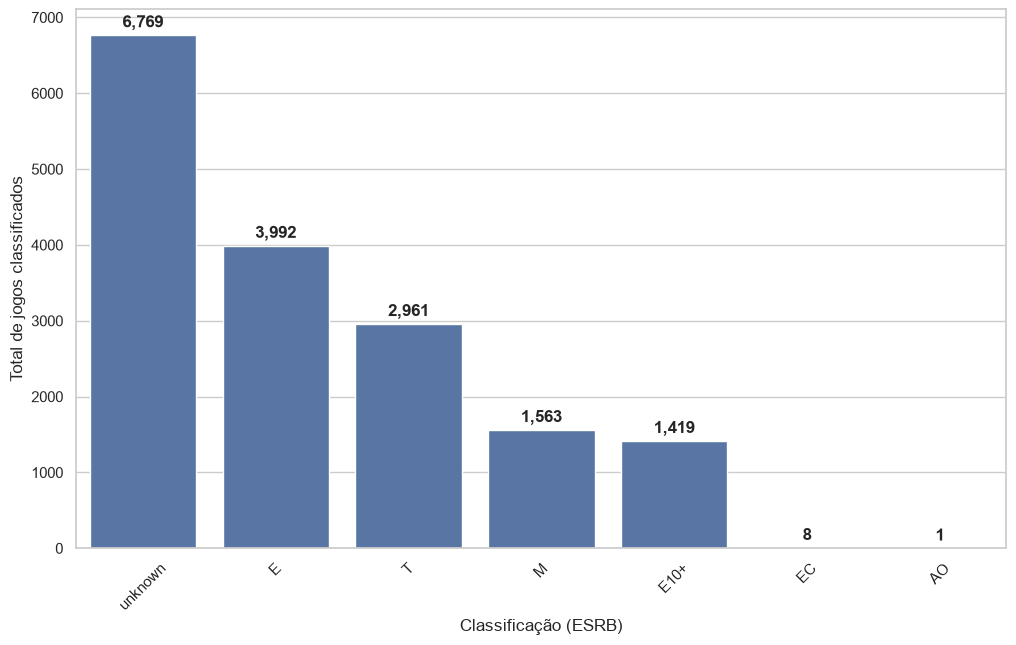

In [195]:
rating_bp = df["rating"].value_counts().reset_index() #DataFrame Object

rating_ax = sns.barplot(data=rating_bp, x="rating", y="count")

# Adiciona rótulos acima de cada barra
for p in rating_ax.patches:
    rating_ax.annotate(
        f'{p.get_height():,.0f}',                       # valor da barra formatado
        (p.get_x() + p.get_width()/2, p.get_height()),  # posição: centro e topo da barra
        ha='center', va='bottom', fontweight='bold',    # alinhamento central e negrito
        xytext=(0, 3), textcoords='offset points'       # deslocamento de 3 pontos acima da barra
    )

plt.xticks(rotation=45)
plt.xlabel(xlabel="Classificação (ESRB)")
plt.ylabel(ylabel="Total de jogos classificados")

plt.show(rating_ax)

Resumindo a tabela para um leitor possivelmente leigo no assunto:
| Classificação   | Significado     | Em português           | Indicação                                                   |
| -------- | --------------- | ---------------------- | ----------------------------------------------------------- |
| **E**    | Everyone        | Todos                  | Geralmente adequado para todas as idades                    |
| **M**    | Mature          | Maduro                 | **17 anos ou mais**                                         |
| **T**    | Teen            | Adolescente            | **13 anos ou mais**                                         |
| **E10+** | Everyone 10+    | Todos 10+              | **10 anos ou mais**                                         |
| **AO**   | Adults Only     | Somente adultos        | **18 anos ou mais**                                         |
| **EC**   | Early Childhood | Primeira infância      | Categoria antiga destinada a crianças pequenas              |

Vale ressaltar que infelizmente a maior parte dos jogos não estão avaliados nesta classfificação, sendo 'unknown' a categoria de maior frequência. Na sequência, temos a categoria E-everyone como a mais frequente, o que seria o "valor esperado" para classificação mais frequente.

Dos jogos que foram classificados, podemos extrair insights interesasntes sobre a faixa etária do público que consumiu o jogo, ou perceber se em alguma das partes cujas vendas estão expostas alguma categoria foi mais vendida que outra, ou apresenta um ordenamento diferente.

## Análise Bivariada:

Nesta etapa vamos nos fazer algumas perguntas e vamos desenvolver a relação que os dados do nosso DataFrame tem entre eles, isto é, tentar identificar se aparentemente há influência clara entre eles.

### `critic_score` X `user_score`:

Vamos analisar a correlação da nota dos críticos com a nota dos usuários. Vale ressaltar antes das visualizações que a prática mais comum no mercado é que sejam publicamente disponibilizadas antes dos lançamentos dos jogos as notas de `critic_score` e começam a medir as notas de `user_score` após o lançamento e definitivamente o consumo dos compradores.

Essa informação de mercado é importante porque já mostra que uma tende a influenciar na outra, e são componentes extramemente importantes para serem avaliados pelo time de marketing.

In [ ]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["critic_score","user_score"]].copy().reset_index(drop=True)
pearson = calculate_pearson(data_to_plot["critic_score"], data_to_plot["user_score"])

# Plotando o gráfico com Seaborn
graph = sns.scatterplot(data=data_to_plot, x='critic_score', y='user_score')

# Define o título do gráfico
plt.title(f'Dispersão: Notas dos Críticos X Notas dos Usuários (Corr. de Pearson:{pearson[0]}-{pearson[1]}-{pearson[2]})')

# Define o rótulo do eixo X
plt.xlabel('Notas dos Críticos')

# Define o rótulo do eixo Y
plt.ylabel('Notas dos Usuários')

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico na tela
plt.show(graph)

Existe uma correlação moderada e positiva entre as notas - o que já era esperado. Vale relembrar - e por esta imagem podemos perceber duas "linhas" que se cruzam - que o gráfico apresenta muitos pontos exatamente onde preenchemos os valores ausentes com a média, e o fato de terem formado essas "linhas visíveis" nos mostra que muitos jogos onde tínhamos valores ausentes em uma coluna, receberam valores bem variados na outra coluba (pontuações bem abaixo da média e também bem acima).

### `total_sales` X `mean_score`:

Já que conseguimos 'condensar' as métricas de vendas e scores em duas colunas princípais com engenharia de características, vamos ver como estas colunas se relacionam:

In [ ]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["total_sales","mean_score"]].copy().reset_index(drop=True)
pearson = calculate_pearson(data_to_plot["total_sales"], data_to_plot["mean_score"])

# Plotando o gráfico com Seaborn
graph = sns.scatterplot(data=data_to_plot, x='total_sales', y='mean_score')

# Define o título do gráfico
plt.title(f'Dispersão: Vendas Totais X Média das Notas (Corr. de Pearson:{pearson[0]}-{pearson[1]}-{pearson[2]})')

# Define o rótulo do eixo X
plt.xlabel('Vendas Totais em Milhões de USD')

# Define o rótulo do eixo Y
plt.ylabel('Média ponderada Críticos X Usuários')

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico na tela
plt.show(graph)

A única coisa que podemos concluir a partir da figura e dos números acima é que neste recorte linear, a correlação entre Vendas Totais e Média das Notas é FRACA, mas isso não prova ausência de efeito. 

Pode-se tratar de um efeito pequeno ou uma relação não linear. Mas é interessante vermos que muitos dos jogos bem avaliados e mal avaliados venderam praticamente o mesmo em números absolutos.

### `total_sales` X `platform`:

Como as vendas totais estão distribuídas dentro das plataformas?

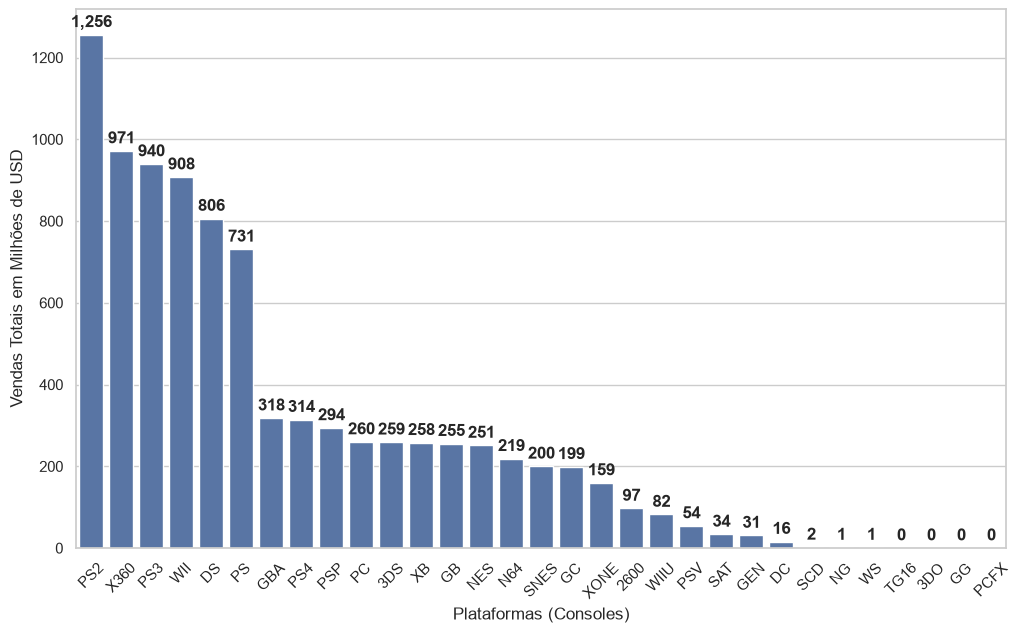

In [216]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["total_sales","platform"]].copy().reset_index(drop=True)
data_to_plot = data_to_plot.groupby("platform")["total_sales"].sum().reset_index()
data_to_plot = data_to_plot.sort_values(by="total_sales", ascending=False)

graph = sns.barplot(data=data_to_plot, x="platform", y="total_sales")

# Adiciona rótulos acima de cada barra
for p in graph.patches:
    graph.annotate(
        f'{p.get_height():,.0f}',                       # valor da barra formatado
        (p.get_x() + p.get_width()/2, p.get_height()),  # posição: centro e topo da barra
        ha='center', va='bottom', fontweight='bold',    # alinhamento central e negrito
        xytext=(0, 3), textcoords='offset points'       # deslocamento de 3 pontos acima da barra
    )

plt.xticks(rotation=45)
plt.xlabel(xlabel="Plataformas (Consoles)")
plt.ylabel(ylabel="Vendas Totais em Milhões de USD")

# Exibe o gráfico na tela
plt.show(graph)

Se voltarmos na análise univariada da coluna Platform, vamos observar que as top 5 plataformas em vendas totais da figura acima também são as plataformas mais presentes no nosso dataframe em números de registros absolutos. 

Tratando-se de somatório da coluna `total_sales`, é natural que elas estejam no TOP5 (mais registros de jogos para somar). 

Vamos observar quanto, em média, um jogo vende em milhões de dólares USD por plataforma.

In [ ]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["total_sales","platform"]].copy().reset_index(drop=True)
data_to_plot = data_to_plot.groupby("platform")["total_sales"].mean().reset_index()
data_to_plot = data_to_plot.sort_values(by="total_sales", ascending=False)

graph = sns.barplot(data=data_to_plot, x="platform", y="total_sales")

# Adiciona rótulos acima de cada barra
for p in graph.patches:
    graph.annotate(
        f'{p.get_height():,.2f}',                       # valor da barra formatado
        (p.get_x() + p.get_width()/2, p.get_height()),  # posição: centro e topo da barra
        ha='center', va='bottom', fontweight='bold',    # alinhamento central e negrito
        xytext=(0, 3), textcoords='offset points'       # deslocamento de 3 pontos acima da barra
    )

plt.xticks(rotation=45)
plt.xlabel(xlabel="Plataformas (Consoles)")
plt.ylabel(ylabel="Vendas Totais em Milhões de USD")

# Exibe o gráfico na tela
plt.show(graph)

Precisamos considerar que o "ticket" médio dos jogos das diferentes plataformas é diferente e isso influencia nas vendas totais, mas é muito interessante observarmos como os jogos de plataformas bem mais antigas venderam em média muito mais - o que não ficava claro analisando o somatório de vendas totais.

### Sales `2` X `2` - Matriz de Dispersão:

Vamos analisar como as colunas de vendas se relacionam visualizando uma matriz de dispersão.

In [ ]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["na_sales","eu_sales","jp_sales",'other_sales']].copy().reset_index(drop=True)

graph = pd.plotting.scatter_matrix(data_to_plot)

plt.show()



Observemos abaixo os índices de correlação linear de pearson entre as colunas de vendas:

In [ ]:
na_x_eu = calculate_pearson(data_to_plot["na_sales"], data_to_plot["eu_sales"])
print(f"Corr. entre vendas na América do Norte e Europa: {na_x_eu[0]} - {na_x_eu[1]} - {na_x_eu[2]}")
print('-'*80)
na_x_jp = calculate_pearson(data_to_plot["na_sales"], data_to_plot["jp_sales"])
print(f"Corr. entre vendas na América do Norte e Japão: {na_x_jp[0]} - {na_x_jp[1]} - {na_x_jp[2]}")
print('-'*80)
na_x_other = calculate_pearson(data_to_plot["na_sales"], data_to_plot["other_sales"])
print(f"Corr. entre vendas na América do Norte e Outras regiões: {na_x_other[0]} - {na_x_other[1]} - {na_x_other[2]}")
print('-'*80)
eu_x_jp = calculate_pearson(data_to_plot["eu_sales"], data_to_plot["jp_sales"])
print(f"Corr. entre vendas na Europa e no Japão: {eu_x_jp[0]} - {eu_x_jp[1]} - {eu_x_jp[2]}")
print('-'*80)
eu_x_other = calculate_pearson(data_to_plot["eu_sales"], data_to_plot["other_sales"])
print(f"Corr. entre vendas na Europa e Outras regiões: {eu_x_other[0]} - {eu_x_other[1]} - {eu_x_other[2]}")
print('-'*80)
jp_x_other = calculate_pearson(data_to_plot["jp_sales"], data_to_plot["other_sales"])
print(f"Corr. entre vendas no Japão e Outras regiões: {jp_x_other[0]} - {jp_x_other[1]} - {jp_x_other[2]}")
print('-'*80)


Com estes resultados é sempre preciso reafirmar que "correlação não implica causalidade".

É claro que o fato de ser bastante vendido na América do Norte é um marco positivo para os produtores dos jogos, e isso tem um potencial claro de que faça sentido também aumentar as campanhas de marketing em outras localidades.

Mas que fique claro o que reforçamos: podemos ter uma causa comum para haver correlação entre vendas NA e EU, o que não significa ainda que as vendas Norte-Americanas são decsivas na decisão de compra do usuário.

USAR CROSSTAB E HEATMAP EM DADOS CATEGÓRICOS

### `year_of_release` X `genre`:

Vamos analisar a quantidade de lançamentos em cada gênero ao longo dos anos.

In [222]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["year_of_release","genre"]].copy().reset_index(drop=True)
data_to_plot = data_to_plot.sort_values('year_of_release').reset_index()
data_to_plot = data_to_plot.groupby(['year_of_release', 'genre'])['index'].count().reset_index()
data_to_plot = data_to_plot.rename(columns={'index': 'count'})

sec_xx = data_to_plot['year_of_release'] < 2001 #Máscara booleana para todos os lançamentos do século 20
sec_xxi = data_to_plot['year_of_release'] >= 2001 #Máscara booleana para todos os lançamentos do século 21


Analisando os lançamentos do Século XX (até o ano 2000):

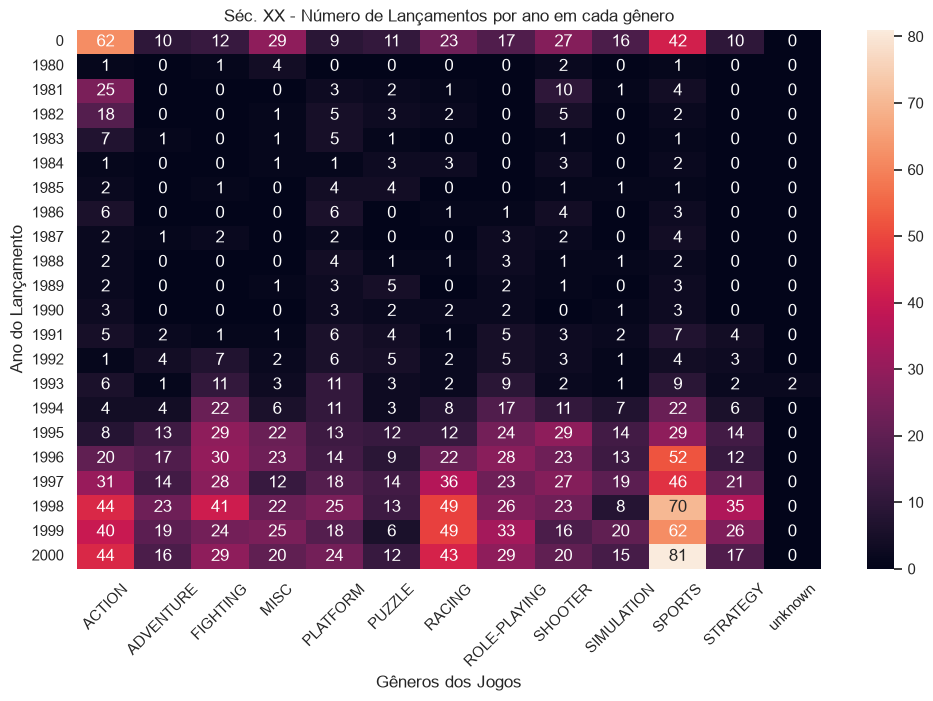

In [223]:
# Separando os anos de lançamento:
df_sec_xx = data_to_plot[sec_xx]
# Reatribuindo um DataFrame tratado à variável df_sec_xx - tabela pivot-table
df_sec_xx = df_sec_xx.pivot_table(index='year_of_release', columns='genre', values='count', fill_value=0)

graph = sns.heatmap(data=df_sec_xx, annot=True, fmt=".0f")
plt.xticks(rotation=45)
plt.title("Séc. XX - Número de Lançamentos por ano em cada gênero")
plt.xlabel("Gêneros dos Jogos")
plt.ylabel("Ano do Lançamento")

plt.show(graph)

Analisando os lançamentos do Século XXI (após o ano 2000):

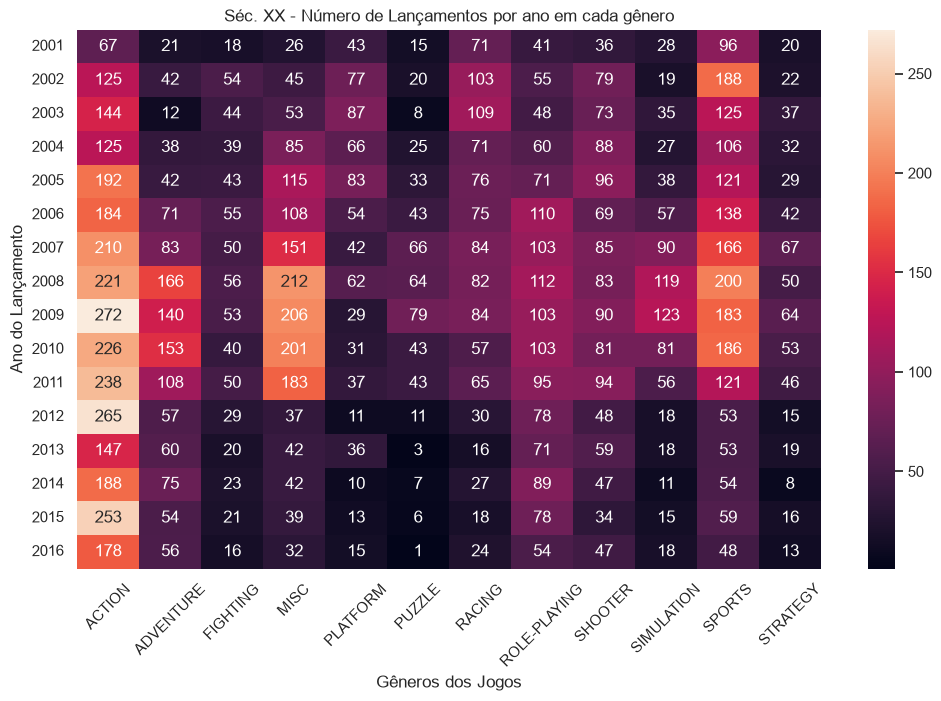

In [224]:
# Separando os anos de lançamento:
df_sec_xxi = data_to_plot[sec_xxi]
# Reatribuindo um DataFrame tratado à variável df_sec_xxi - tabela pivot-table
df_sec_xxi = df_sec_xxi.pivot_table(index='year_of_release', columns='genre', values='count', fill_value=0)

graph = sns.heatmap(data=df_sec_xxi, annot=True, fmt=".0f")
plt.xticks(rotation=45)
plt.yticks(rotation=1)
plt.title("Séc. XX - Número de Lançamentos por ano em cada gênero")
plt.xlabel("Gêneros dos Jogos")
plt.ylabel("Ano do Lançamento")

plt.show(graph)

Observando a quantidade de lançamentos de jogos de cada gênero no Século XX e XXI, podemos observar uma verdadeira crescente observando como mercado se expandiu no século XXI em quantidades de jogos disponíveis em todas as categorias.

Mas vale destacar o grande momento em todos os gêneros que foi entre 2005 e 2012. Esta faixa 2005-2012 representou o ápice do número de lançamentos em todos os gêneros no século XXI. 

Nossos destaques são Ação e Sports, que parecem ser requisitados desde o Séc. XX, Role-Playing que conquistou mais destaque no Séc. XXI e miscelaneous - jogos diversos.

### `year_of_release` X `platform`:

Vamos analisar a quantidade de lançamentos de cada plataforma ao longo dos anos.

In [217]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["year_of_release","platform"]].copy().reset_index(drop=True)
data_to_plot = data_to_plot.sort_values('year_of_release').reset_index()
data_to_plot = data_to_plot.groupby(['year_of_release', 'platform'])['index'].count().reset_index()
data_to_plot = data_to_plot.rename(columns={'index': 'count'})

sec_xx = data_to_plot['year_of_release'] < 2001 #Máscara booleana para todos os lançamentos do século 20
sec_xxi = data_to_plot['year_of_release'] >= 2001 #Máscara booleana para todos os lançamentos do século 21


Analisando os lançamentos do Século XX (até o ano 2000):

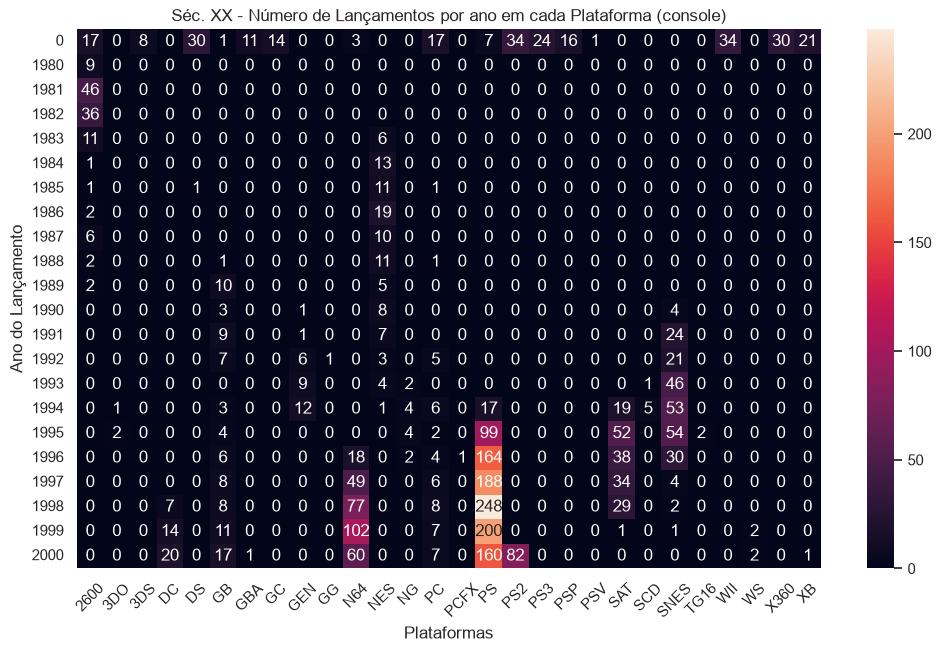

In [218]:
# Separando os anos de lançamento:
df_sec_xx = data_to_plot[sec_xx]
# Reatribuindo um DataFrame tratado à variável df_sec_xx - tabela pivot-table
df_sec_xx = df_sec_xx.pivot_table(index='year_of_release', columns='platform', values='count', fill_value=0)

graph = sns.heatmap(data=df_sec_xx, annot=True, fmt=".0f")
plt.xticks(rotation=45)
plt.title("Séc. XX - Número de Lançamentos por ano em cada Plataforma (console)")
plt.xlabel("Plataformas")
plt.ylabel("Ano do Lançamento")

plt.show(graph)

Analisando os lançamentos do Século XXI (após o ano 2000):

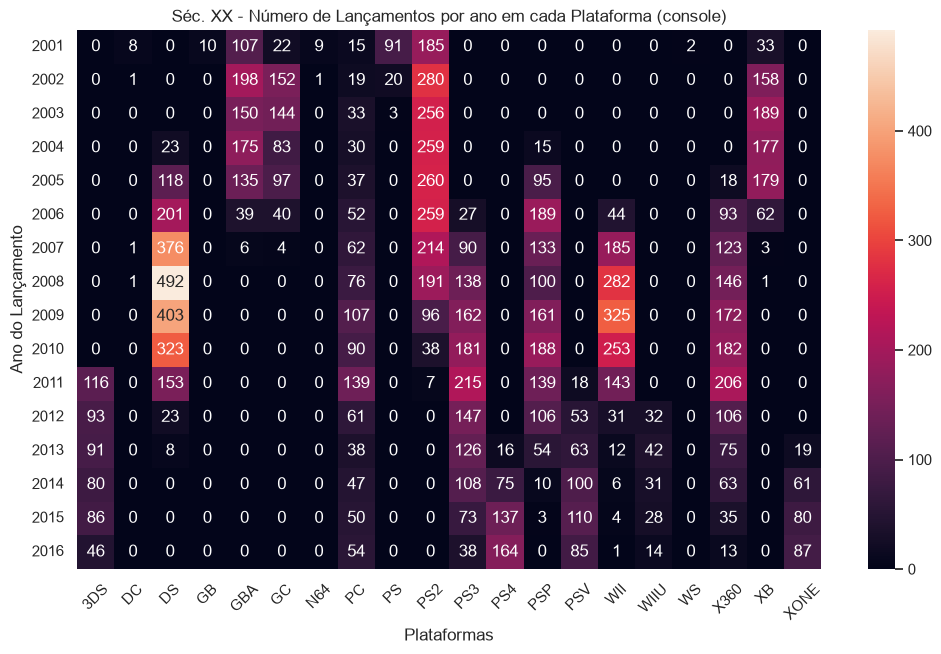

In [219]:
# Separando os anos de lançamento:
df_sec_xxi = data_to_plot[sec_xxi]
# Reatribuindo um DataFrame tratado à variável df_sec_xxi - tabela pivot-table
df_sec_xxi = df_sec_xxi.pivot_table(index='year_of_release', columns='platform', values='count', fill_value=0)

graph = sns.heatmap(data=df_sec_xxi, annot=True, fmt=".0f")
plt.xticks(rotation=45)
plt.yticks(rotation=1)
plt.title("Séc. XX - Número de Lançamentos por ano em cada Plataforma (console)")
plt.xlabel("Plataformas")
plt.ylabel("Ano do Lançamento")

plt.show(graph)

Esses gráficos são extremamente interessantes para que nós consigamos observar os ciclos de mercado de lançamento de jogos em cada plataforma. 

Porque nele, além de saber quais foram as plataformas mais populares ao longo dos anos, também conseguimos nitidamente ver o início e o fim do lançamento de jogos em algumas plataformas - e até mesmo as que concorreram entre si na mesma cronologia.

### `genre` X `rating`:

Vamos remover desta análise os registros do DataFrame que não possuem Avaliação de `rating`, visto que são muitos e com certeza geraria uma poluição desnecessária no nosso gráfico.

A nossa ideia é entender como os "ratings" se distribuem pelos gêneros dos jogos.

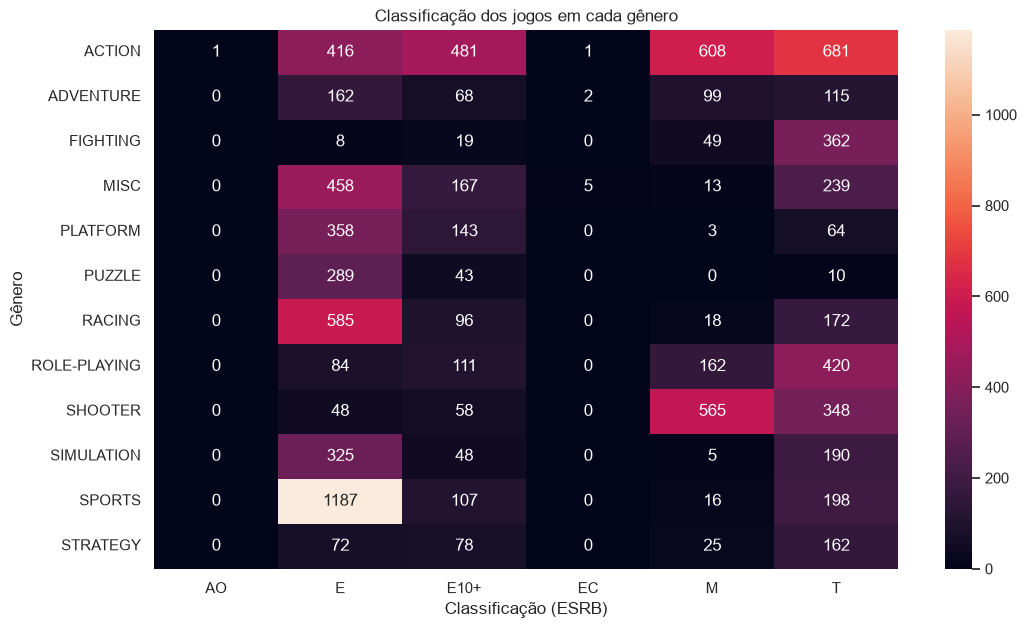

In [210]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["genre","rating"]].copy().reset_index(drop=True)
unknown_rating = data_to_plot["rating"] == 'unknown'
data_to_plot = data_to_plot[~unknown_rating].reset_index()
# Atribuindo à variável data_to_plot um DataFrame devidamente agrupado
data_to_plot = data_to_plot.groupby(['genre', 'rating'])['index'].count().reset_index()
data_to_plot = data_to_plot.rename(columns={'index': 'count'})
# Criando uma Tabela Pivotada:
data_to_plot = data_to_plot.pivot_table(index='genre', columns='rating', values='count', fill_value=0)

graph = sns.heatmap(data=data_to_plot, annot=True, fmt=".0f")

plt.title("Classificação dos jogos em cada gênero")
plt.xlabel("Classificação (ESRB)")
plt.ylabel("Gênero")

plt.show(graph)


Observando o gráfico acima, conseguimos perceber que, dentro dos jogos classificados, existe uma grande demanda por jogos abertos a todos os públicos ou bem nichados para o público teen.

Enquanto os jogos para público M (17+) são geralmente de ação e tiro.

### `genre` X `platform`:

Vamos tentar observar como cada gênero se distribui nos lançamentos de cada plataforma.

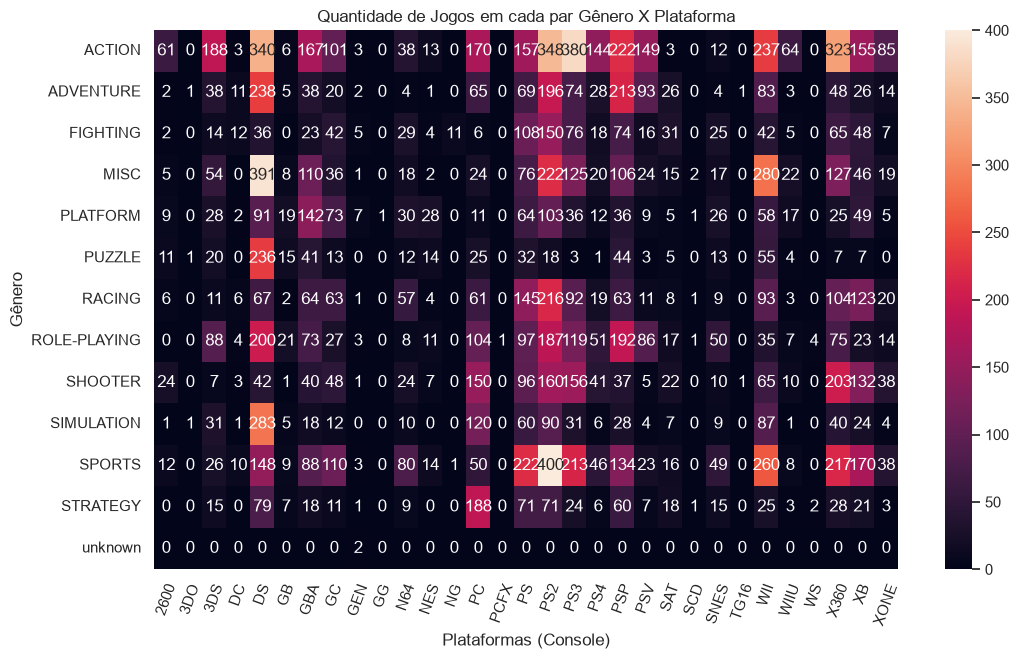

In [215]:
# Gerando o DataFrame com os dados relevantes
data_to_plot = df[["genre","platform"]].copy().reset_index()
# Atribuindo à variável data_to_plot um DataFrame devidamente agrupado
data_to_plot = data_to_plot.groupby(['genre', 'platform'])['index'].count().reset_index()
data_to_plot = data_to_plot.rename(columns={'index': 'count'})
# Criando uma Tabela Pivotada:
data_to_plot = data_to_plot.pivot_table(index='genre', columns='platform', values='count', fill_value=0)

graph = sns.heatmap(data=data_to_plot, annot=True, fmt=".0f")

plt.title("Quantidade de Jogos em cada par Gênero X Plataforma")
plt.xlabel("Plataformas (Console)")
plt.ylabel("Gênero")
plt.xticks(rotation=70)

plt.show(graph)


Acredito que o Insight mais relevante para extrairmos deste gráfico é observarmos a semelhança no número de lançamentos dos mesmo gêneros em todas as plataformas Sony (Playstation: PS, PS2, PS3, PS4, PSP) e também da Microsoft (Xbox: X360, XB, XONE) - sendo visível que PS4 e XONE que são as novidades do ano de 2016, ainda nos seus primeiros anos de ciclo de mercado, ainda terão mais lançamentos dos respectivos gêneros. 

Há uma semelhança também entre DS e WII da Nintendo, e portanto uma expectativa de termos ainda um ciclo de mercado do WiiU para os próximos anos, já que elee foi lançado em 2012 e ainda não teve o mesmo sucesso..

# EDA

Partiremos para a nossa _Exploratory Data Analysis_ orientada a algumas perguntas que definiremos abaixo.

### Os dados de cada período são significativos?

Quando analisamos os dados só da coluna `year_of_release`, podemos observar no gráfico de linhas que a maior quantidade de lançamentos foi partir de 2006. 

Se nós observarmos o gráfico "heatmap" de `year_of_release X genre` e `year_of_release X platform`, podemos concluir que realmente a massa mais significativa para nossa análise os dados visando o ano de 2017 é a última década. Por alguns dos seguintes fatores:

- Ciclo de mercado das plataformas não dura mais de 10 anos - olhe `year_of_release X platform`
- Os comportamentos de plataformas semelhantes (mesma fabricante) pareceu semelhante se olharmos para `genre X platform` acima
- Podemos observar o início do ciclo de vida das plataformas mais recentemente lançadas no final desse período

Doravante, nossas análises seguirão o DataFrame abaixo:

In [225]:
# Definir DF main como year of release acima de 2006